# Forecasting German Electricity Demand — Time-Series Case Study

**Student ID:** 24090973

This notebook models and forecasts **weekly German electricity load** (country code `DE`, Open Power System Data, hourly data 2015-01-01 → Oct 2020) using a ladder of models from trivial benchmarks up to an LSTM, and compares them on a common **104-week (2-year) test horizon**.


In [1]:
# ======================================================================
# SETUP  —  run this cell first
# Shared imports, constants, output folders, and helper functions used by
# every Part (metrics incl. MASE & Bias, seasonal-naive, cached temperature
# download, and save/load helpers so Part 7 can assemble every forecast).
# ======================================================================
import os, json, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
np.random.seed(42)

# --- Global forecasting settings (shared by every Part) ---
H = 104                                           # test length / horizon in weeks (2 yrs)
S = 52                                            # weekly seasonal period (annual)
BERLIN = dict(latitude=52.52, longitude=13.41)    # representative German location
START_DATE, END_DATE = "2015-01-01", "2020-10-31"

# --- Output folders (mirror the README repo layout) ---
FIG_DIR = Path("outputs/figures");   FIG_DIR.mkdir(parents=True, exist_ok=True)
FC_DIR  = Path("outputs/forecasts"); FC_DIR.mkdir(parents=True, exist_ok=True)
MET_DIR = Path("outputs/metrics");   MET_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------
# Evaluation metrics  (README requires MAE, RMSE, MASE, Bias)
# ----------------------------------------------------------------------
def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def bias(y_true, y_pred):
    # mean forecast error;  > 0 => forecast is too HIGH on average
    return float(np.mean(np.asarray(y_pred, float) - np.asarray(y_true, float)))

def mase(y_true, y_pred, y_train, m=S):
    # Hyndman seasonal MASE: error scaled by the in-sample one-step
    # SEASONAL-naive MAE on the TRAINING set.  MASE < 1 beats that baseline.
    y_train = np.asarray(y_train, float)
    denom = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return np.nan if denom == 0 else float(mae(y_true, y_pred) / denom)

def build_metric_table(forecasts, y_true, y_train, m=S):
    """forecasts: {name -> Series}.  Returns a tidy metrics DataFrame."""
    rows = []
    for name, fc in forecasts.items():
        fc = pd.Series(fc).reindex(y_true.index)
        ok = fc.notna()                                    # compare only overlapping weeks
        rows.append({
            "model": name,
            "n":     int(ok.sum()),
            "MAE":   round(mae(y_true[ok], fc[ok]), 1),
            "RMSE":  round(rmse(y_true[ok], fc[ok]), 1),
            "MASE":  round(mase(y_true[ok], fc[ok], y_train, m), 3),
            "Bias":  round(bias(y_true[ok], fc[ok]), 1),
        })
    tbl = pd.DataFrame(rows).set_index("model").sort_values("MASE")
    if "seasonal_naive" in tbl.index:                      # RMSE reduction vs the benchmark
        base = tbl.loc["seasonal_naive", "RMSE"]
        tbl["RMSE_skill_vs_snaive_%"] = ((base - tbl["RMSE"]) / base * 100).round(1)
    return tbl

# ----------------------------------------------------------------------
# Seasonal-naive helper (the reference benchmark used everywhere)
# ----------------------------------------------------------------------
def seasonal_naive_forecast(train, horizon, m, index):
    last = train.iloc[-m:].to_numpy()
    reps = int(np.ceil(horizon / m))
    return pd.Series(np.tile(last, reps)[:horizon], index=index)

# ----------------------------------------------------------------------
# Save / load individual model forecasts so Part 7 can assemble them all
# ----------------------------------------------------------------------
def save_forecast(name, series):
    pd.Series(series).rename("forecast").to_frame().to_csv(FC_DIR / f"{name}.csv")
    print(f"  saved forecast -> {FC_DIR / (name + '.csv')}")

def load_all_forecasts():
    out = {}
    for f in sorted(glob.glob(str(FC_DIR / "*.csv"))):
        name = Path(f).stem
        out[name] = pd.read_csv(f, index_col=0, parse_dates=True).squeeze("columns")
    return out

# ----------------------------------------------------------------------
# Berlin temperature -> weekly degree-day features, cached to disk so the
# Open-Meteo archive is fetched only ONCE (Parts 4 and 5 share this).
# ----------------------------------------------------------------------
TEMP_CACHE = "weekly_temperature.csv"
def get_weekly_temperature(base=18.0):
    if os.path.exists(TEMP_CACHE):
        return pd.read_csv(TEMP_CACHE, index_col=0, parse_dates=True)
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {**BERLIN, "start_date": START_DATE, "end_date": END_DATE,
              "daily": "temperature_2m_mean", "timezone": "UTC"}
    r = requests.get(url, params=params, timeout=60); r.raise_for_status()
    j = r.json()["daily"]
    temp = pd.Series(j["temperature_2m_mean"],
                     index=pd.to_datetime(j["time"]).tz_localize("UTC"), name="temp_C")
    # Load-temperature link is U-shaped; degree days linearise it:
    #   HDD = max(0, base - T)  (cold -> heating);  CDD = max(0, T - base)  (hot -> cooling)
    daily = pd.DataFrame({"temp_mean": temp,
                          "hdd": np.clip(base - temp, 0, None),
                          "cdd": np.clip(temp - base, 0, None)})
    weekly_temp = daily.resample("W").mean()
    weekly_temp.to_csv(TEMP_CACHE)
    return weekly_temp

print(f"Setup complete.  H = {H} weeks, S = {S}.  Outputs -> {FIG_DIR.parent}/")

Setup complete.  H = 104 weeks, S = 52.  Outputs -> outputs/


## Part 1 — Data retrieval, EDA, and stationarity


2015-01-01 00:00:00+00:00 -> 2020-09-30 23:00:00+00:00
Missing hourly values: 0
weekly series: 299 weeks, 2015-01-11 -> 2020-09-27


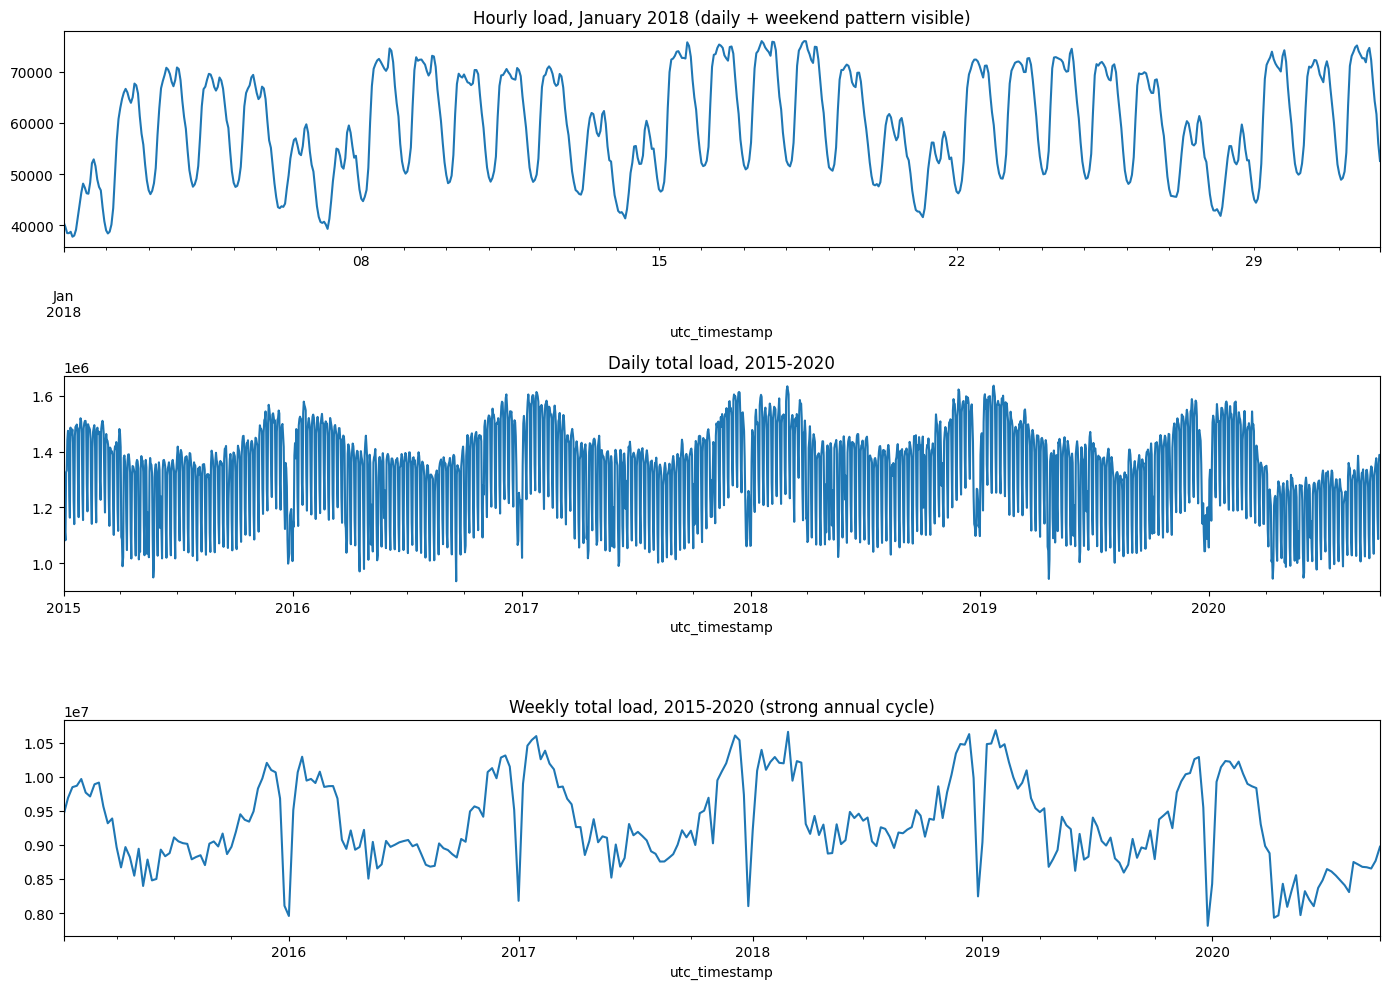

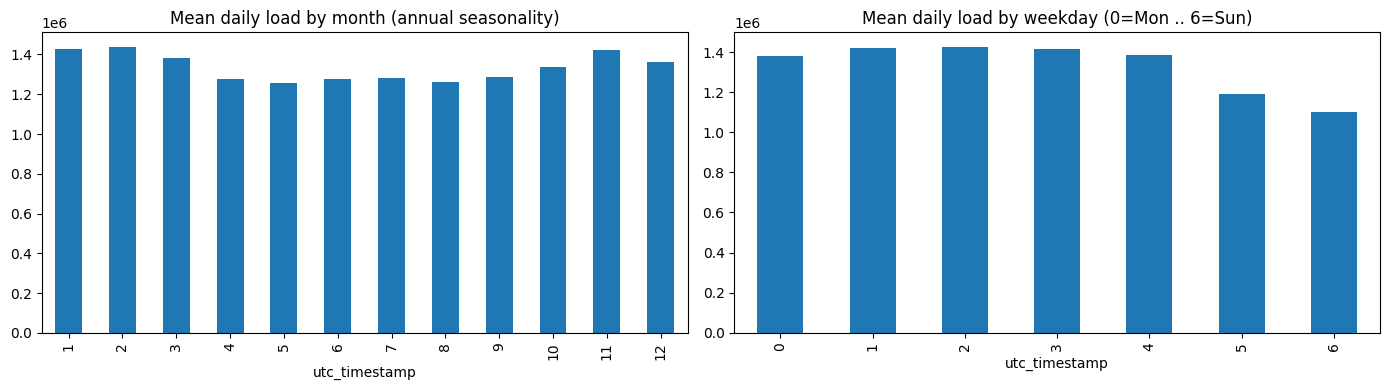

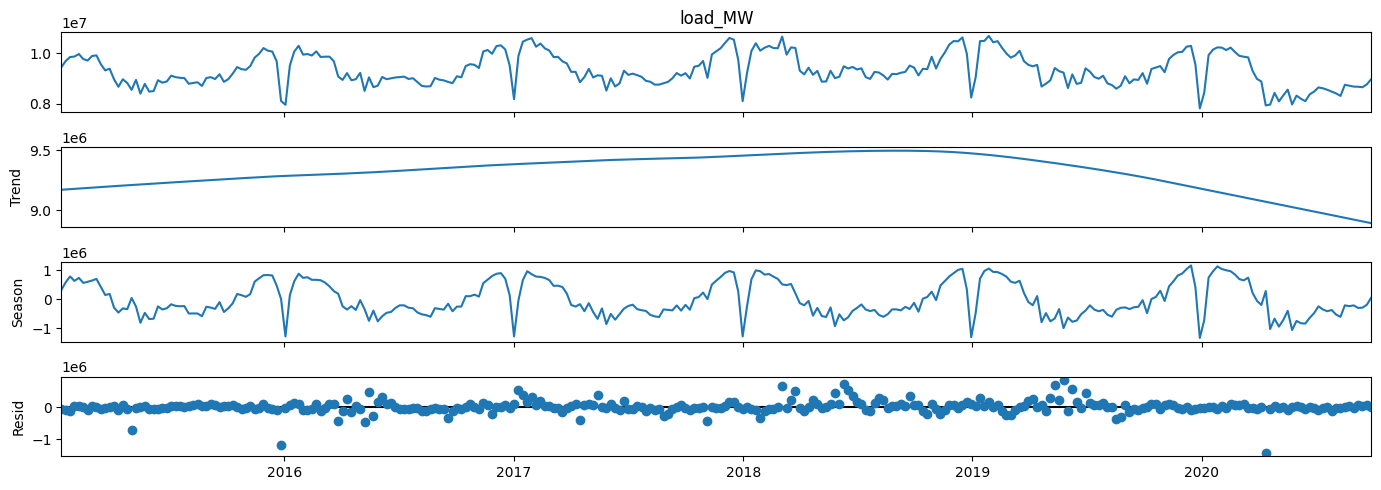

ADF  | weekly load: stat=-3.900, p=0.0020 (stationary)
KPSS | weekly load: stat=0.163, p=0.1000 (stationary)
ADF  | seasonal diff (52): stat=-1.804, p=0.3784 (non-stationary)
KPSS | seasonal diff (52): stat=1.424, p=0.0100 (non-stationary)
ADF  | seasonal + first diff: stat=-7.690, p=0.0000 (stationary)
KPSS | seasonal + first diff: stat=0.035, p=0.1000 (stationary)


/tmp/ipykernel_717/3330485321.py:73: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_717/3330485321.py:73: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_717/3330485321.py:73: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(series.dropna(), regression="c", nlags="auto")


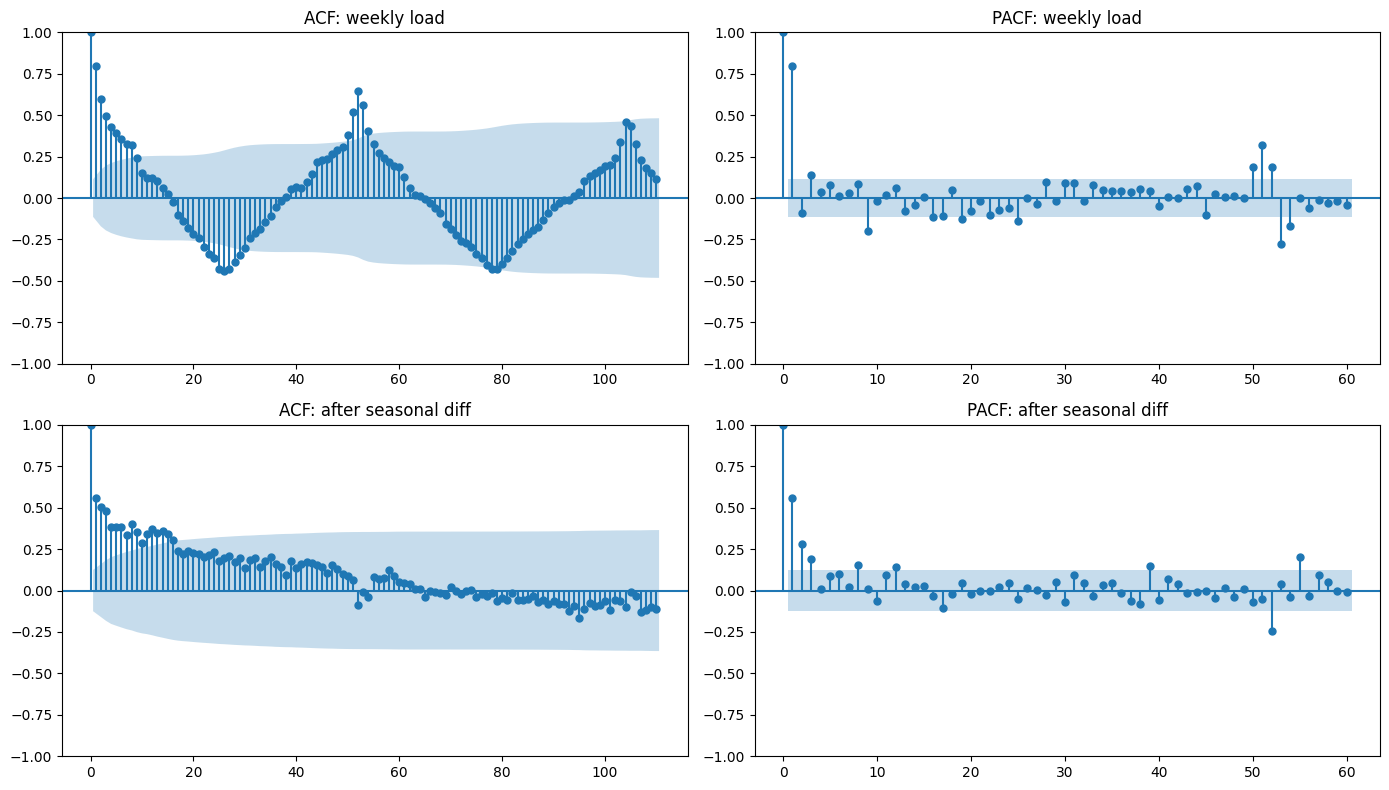

In [2]:
# ======================================================================
# PART 1 — retrieve data, EDA, stationarity tests
# ======================================================================
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ----------------------------------------------------------------------
# 1. Retrieve the data (load only the columns we need; the file is large)
# ----------------------------------------------------------------------
URL = ("https://data.open-power-system-data.org/time_series/"
       "2020-10-06/time_series_60min_singleindex.csv")
USE_COLS = ["utc_timestamp", "DE_load_actual_entsoe_transparency"]

df = pd.read_csv(URL, usecols=USE_COLS, parse_dates=["utc_timestamp"],
                 index_col="utc_timestamp")
df = df.rename(columns={"DE_load_actual_entsoe_transparency": "load_MW"})  # units: MW

# ----------------------------------------------------------------------
# 2. Keep 2015-01-01 -> end of file (Oct 2020); interpolate only short gaps
# ----------------------------------------------------------------------
df = df.loc["2015-01-01":]
print(df.index.min(), "->", df.index.max())
print("Missing hourly values:", int(df["load_MW"].isna().sum()))
df["load_MW"] = df["load_MW"].interpolate(limit=6)   # short gaps only (documented choice)

# ----------------------------------------------------------------------
# 3. Bin to daily and weekly totals (sum of MW over the period = MWh)
# ----------------------------------------------------------------------
daily  = df["load_MW"].resample("D").sum()
weekly = df["load_MW"].resample("W").sum()
weekly = weekly.iloc[1:-1]                 # drop partial first/last weeks

daily.to_csv("de_load_daily.csv")
weekly.to_csv("de_load_weekly.csv")
df.to_csv("de_load_hourly.csv")            # hourly series is used by the LSTM in Part 6
print(f"weekly series: {len(weekly)} weeks, "
      f"{weekly.index.min().date()} -> {weekly.index.max().date()}")

# ----------------------------------------------------------------------
# 4. Initial plots / EDA
# ----------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
df["load_MW"].loc["2018-01-01":"2018-01-31"].plot(
    ax=axes[0], title="Hourly load, January 2018 (daily + weekend pattern visible)")
daily.plot(ax=axes[1],  title="Daily total load, 2015-2020")
weekly.plot(ax=axes[2], title="Weekly total load, 2015-2020 (strong annual cycle)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig01_load_overview.png", dpi=150); plt.show()

# Seasonal sub-series: mean load by month and by day-of-week
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily.groupby(daily.index.month).mean().plot(
    kind="bar", ax=axes[0], title="Mean daily load by month (annual seasonality)")
daily.groupby(daily.index.dayofweek).mean().plot(
    kind="bar", ax=axes[1], title="Mean daily load by weekday (0=Mon .. 6=Sun)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig02_seasonal_patterns.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 5. STL decomposition of the weekly series (period ~52)
# ----------------------------------------------------------------------
stl = STL(weekly, period=S, robust=True).fit()
stl.plot(); plt.savefig(FIG_DIR / "fig03_stl_decomposition.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 6. Stationarity tests (ADF null = unit root; KPSS null = stationary)
# ----------------------------------------------------------------------
def adf_report(series, name):
    stat, p, *_ = adfuller(series.dropna())
    print(f"ADF  | {name}: stat={stat:.3f}, p={p:.4f} "
          f"({'stationary' if p < 0.05 else 'non-stationary'})")

def kpss_report(series, name):
    stat, p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"KPSS | {name}: stat={stat:.3f}, p={p:.4f} "
          f"({'non-stationary' if p < 0.05 else 'stationary'})")

adf_report(weekly, "weekly load")
kpss_report(weekly, "weekly load")

weekly_sdiff    = weekly.diff(S)            # seasonal differencing at lag 52
weekly_sdiff_d1 = weekly_sdiff.diff(1)      # + first differencing
adf_report(weekly_sdiff,    "seasonal diff (52)")
kpss_report(weekly_sdiff,   "seasonal diff (52)")
adf_report(weekly_sdiff_d1, "seasonal + first diff")
kpss_report(weekly_sdiff_d1, "seasonal + first diff")

# ACF / PACF — visual check for autocorrelation and the annual spike
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(weekly,  lags=110, ax=axes[0, 0], title="ACF: weekly load")
plot_pacf(weekly, lags=60,  ax=axes[0, 1], title="PACF: weekly load")
plot_acf(weekly_sdiff.dropna(),  lags=110, ax=axes[1, 0], title="ACF: after seasonal diff")
plot_pacf(weekly_sdiff.dropna(), lags=60,  ax=axes[1, 1], title="PACF: after seasonal diff")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig04_acf_pacf.png", dpi=150); plt.show()

## Part 2 — Benchmark forecasts (Mean, Naive, Seasonal naive, Drift)



Train: 2015-01-11 -> 2018-09-30 (195 weeks)
Test:  2018-10-07 -> 2020-09-27 (104 weeks)


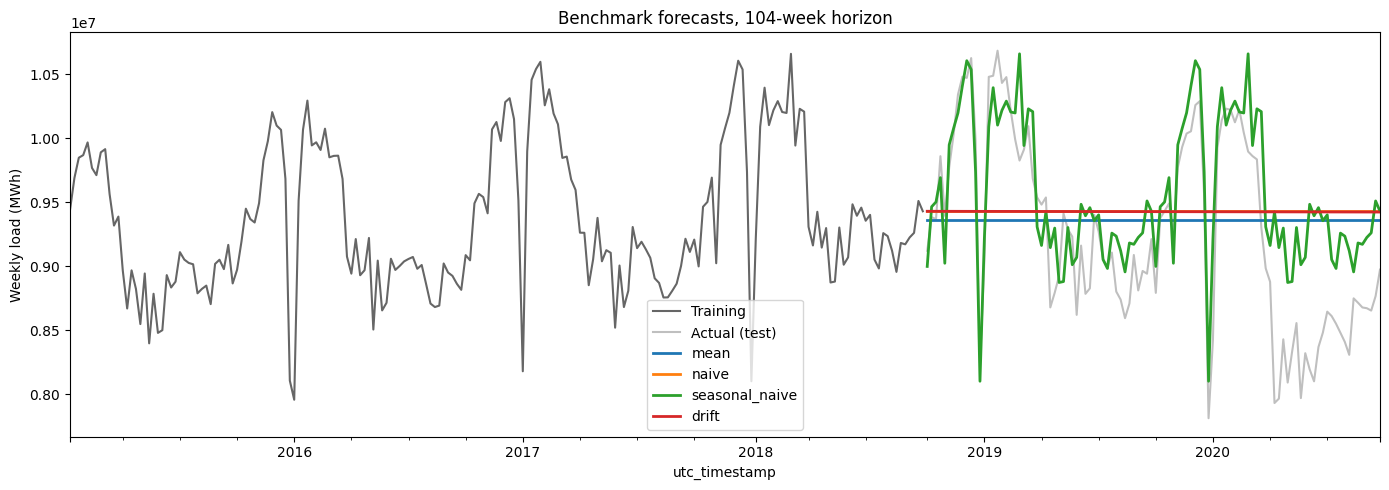


Benchmark metrics:
                  n       MAE      RMSE   MASE      Bias  \
model                                                      
seasonal_naive  104  384466.2  502025.7  1.694  293631.2   
mean            104  636694.0  739545.9  2.805   94280.3   
drift           104  646930.3  750371.1  2.850  162352.8   
naive           104  648168.8  751928.9  2.856  165401.6   

                RMSE_skill_vs_snaive_%  
model                                   
seasonal_naive                     0.0  
mean                             -47.3  
drift                            -49.5  
naive                            -49.8  
  saved forecast -> outputs/forecasts/mean.csv
  saved forecast -> outputs/forecasts/naive.csv
  saved forecast -> outputs/forecasts/seasonal_naive.csv
  saved forecast -> outputs/forecasts/drift.csv


In [3]:
# ======================================================================
# PART 2 — benchmark forecasts on the weekly series
# ======================================================================
weekly = pd.read_csv("de_load_weekly.csv", index_col=0,
                     parse_dates=True).squeeze("columns")

train, test = weekly.iloc[:-H], weekly.iloc[-H:]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} weeks)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} weeks)")

# --- Benchmarks, all built from the training set only ---
forecasts = {}
forecasts["mean"]  = pd.Series(train.mean(),     index=test.index)         # long-run mean
forecasts["naive"] = pd.Series(train.iloc[-1],   index=test.index)         # last observed value
forecasts["seasonal_naive"] = seasonal_naive_forecast(train, H, S, test.index)  # same week last yr
slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)                # drift = avg trend
forecasts["drift"] = pd.Series(train.iloc[-1] + slope * np.arange(1, H + 1), index=test.index)

# --- Plot ---
ax = train.plot(label="Training", color="black", alpha=0.6)
test.plot(ax=ax, label="Actual (test)", color="black", alpha=0.25)
for name, fc in forecasts.items():
    fc.plot(ax=ax, label=name, linewidth=2)
ax.set_title("Benchmark forecasts, 104-week horizon"); ax.set_ylabel("Weekly load (MWh)")
ax.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_benchmark_forecasts.png", dpi=150); plt.show()

# --- Metrics + save each forecast for the Part 7 comparison ---
print("\nBenchmark metrics:")
print(build_metric_table(forecasts, test, train, S))
for name, fc in forecasts.items():
    save_forecast(name, fc)

## Part 3 — SARIMA (grid search by AIC, residual diagnostics, forecast)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


SARIMA(0,0,0)(0,1,0,52)  AIC=4003.7


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


SARIMA(0,0,0)(0,1,1,52)  AIC=2530.3


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


SARIMA(6,2,6)(1,1,0,52)  AIC=2326.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


SARIMA(6,2,6)(1,1,1,52)  AIC=2295.2

Top 5 models by AIC:
     p  d  q  P  D  Q          AIC
251  2  2  6  1  1  1  2286.398743
167  1  2  6  1  1  1  2289.845569
419  4  2  6  1  1  1  2292.378461
165  1  2  6  0  1  1  2293.468930
333  3  2  6  0  1  1  2293.551533

Best model: SARIMA(2, 2, 6)(1, 1, 1, 52)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


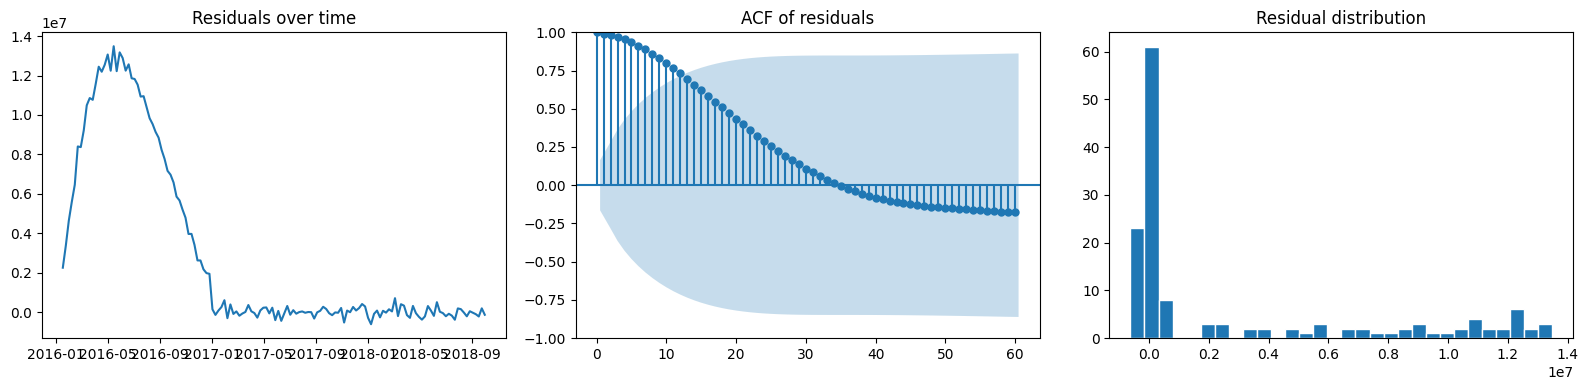


Ljung-Box test on residuals:
         lb_stat      lb_pvalue
10  1251.664808  1.030010e-262
20  1850.199078   0.000000e+00
52  2019.544116   0.000000e+00


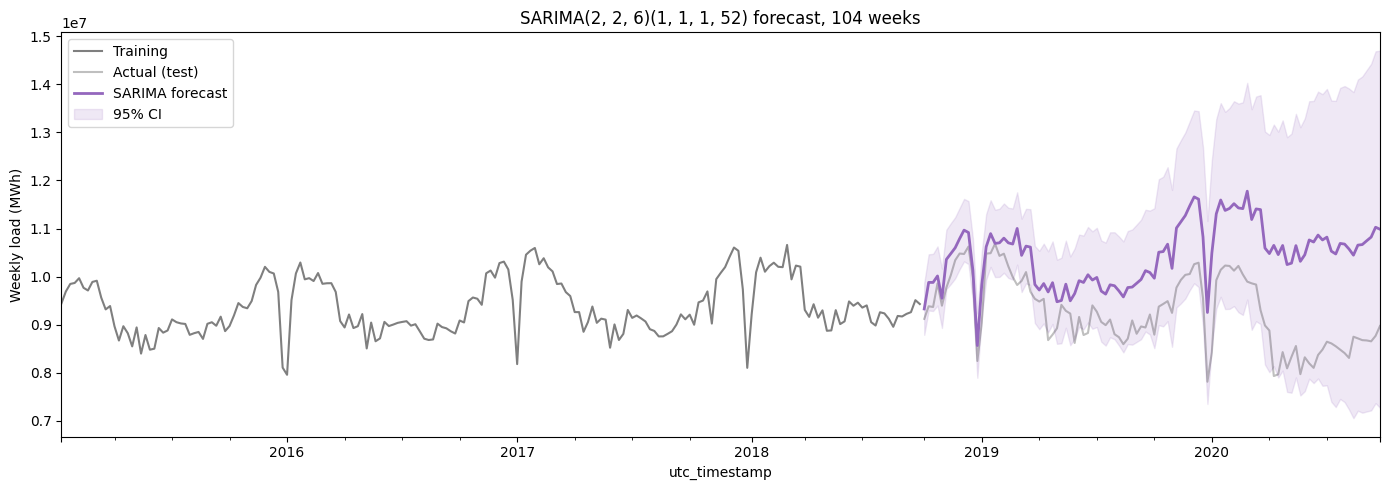


SARIMA vs seasonal naive:
                  n        MAE       RMSE   MASE       Bias  \
model                                                         
seasonal_naive  104   384466.2   502025.7  1.694   293631.2   
sarima          104  1187632.6  1388509.7  5.232  1187632.6   

                RMSE_skill_vs_snaive_%  
model                                   
seasonal_naive                     0.0  
sarima                          -176.6  

95% CI coverage: 90.4% of test points inside the interval (nominal 95%)
  saved forecast -> outputs/forecasts/sarima.csv


In [4]:
# ======================================================================
# PART 3 — SARIMA: AIC grid search, diagnostics, 104-week forecast
# ======================================================================
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

weekly = pd.read_csv("de_load_weekly.csv", index_col=0,
                     parse_dates=True).squeeze("columns")
train, test = weekly.iloc[:-H], weekly.iloc[-H:]

# ----------------------------------------------------------------------
# 1. Grid search over (p,d,q)(P,D,Q,52) by AIC  (cached to CSV)
# ----------------------------------------------------------------------
FULL_GRID = True                       # True -> d in {0,1,2} (brief); False -> {0,1} (fast)
GRID_CSV  = "sarima_grid_search.csv"

if os.path.exists(GRID_CSV):
    results_df = pd.read_csv(GRID_CSV).sort_values("AIC")
    print(f"Loaded cached grid search ({len(results_df)} models) from {GRID_CSV}")
else:
    p_range = range(0, 7)
    d_range = [0, 1, 2] if FULL_GRID else [0, 1]
    q_range = range(0, 7)
    P_range, Q_range, D_FIXED = [0, 1], [0, 1], 1     # D=1 justified by seasonal diff test
    results = []
    for p, d, q, P, Q in itertools.product(p_range, d_range, q_range, P_range, Q_range):
        try:
            fit = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D_FIXED, Q, S),
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, maxiter=200)
            results.append({"p": p, "d": d, "q": q, "P": P, "D": D_FIXED, "Q": Q,
                            "AIC": fit.aic})
            print(f"SARIMA({p},{d},{q})({P},{D_FIXED},{Q},{S})  AIC={fit.aic:.1f}")
        except Exception:
            continue
    results_df = pd.DataFrame(results).sort_values("AIC")
    results_df.to_csv(GRID_CSV, index=False)

print("\nTop 5 models by AIC:")
print(results_df.head())

best = results_df.iloc[0]
best_order    = (int(best.p), int(best.d), int(best.q))
best_seasonal = (int(best.P), int(best.get("D", 1)), int(best.Q), S)
print(f"\nBest model: SARIMA{best_order}{best_seasonal}")

# Persist the winning order so Part 4 (SARIMAX) reuses it instead of hard-coding
with open("outputs/best_sarima_order.json", "w") as f:
    json.dump({"order": list(best_order), "seasonal_order": list(best_seasonal)}, f)

# ----------------------------------------------------------------------
# 2. Fit the best model and inspect residuals
# ----------------------------------------------------------------------
best_fit = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

resid = best_fit.resid.iloc[S + 1:]                 # drop differencing burn-in
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(resid); axes[0].set_title("Residuals over time")
plot_acf(resid, lags=60, ax=axes[1], title="ACF of residuals")
axes[2].hist(resid, bins=30, edgecolor="white"); axes[2].set_title("Residual distribution")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig06_sarima_residuals.png", dpi=150); plt.show()

lb = acorr_ljungbox(resid, lags=[10, 20, 52], return_df=True)   # H0: no leftover autocorr
print("\nLjung-Box test on residuals:\n", lb)

# ----------------------------------------------------------------------
# 3. Forecast 104 weeks with a 95% interval
# ----------------------------------------------------------------------
fc = best_fit.get_forecast(steps=H)
fc_mean, fc_ci = fc.predicted_mean, fc.conf_int(alpha=0.05)

ax = train.plot(label="Training", color="black", alpha=0.5)
test.plot(ax=ax, label="Actual (test)", color="black", alpha=0.25)
fc_mean.plot(ax=ax, label="SARIMA forecast", color="tab:purple", linewidth=2)
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color="tab:purple", alpha=0.15, label="95% CI")
ax.set_title(f"SARIMA{best_order}{best_seasonal} forecast, 104 weeks")
ax.set_ylabel("Weekly load (MWh)"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig07_sarima_forecast.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 4. Metrics vs the seasonal-naive benchmark + interval coverage
# ----------------------------------------------------------------------
snaive = seasonal_naive_forecast(train, H, S, test.index)
print("\nSARIMA vs seasonal naive:")
print(build_metric_table({"sarima": fc_mean, "seasonal_naive": snaive}, test, train, S))

coverage = ((test >= fc_ci.iloc[:, 0]) & (test <= fc_ci.iloc[:, 1])).mean()
print(f"\n95% CI coverage: {coverage:.1%} of test points inside the interval "
      f"(nominal 95%)")

save_forecast("sarima", fc_mean)

## Part 4 — SARIMAX with temperature (conditional forecast)



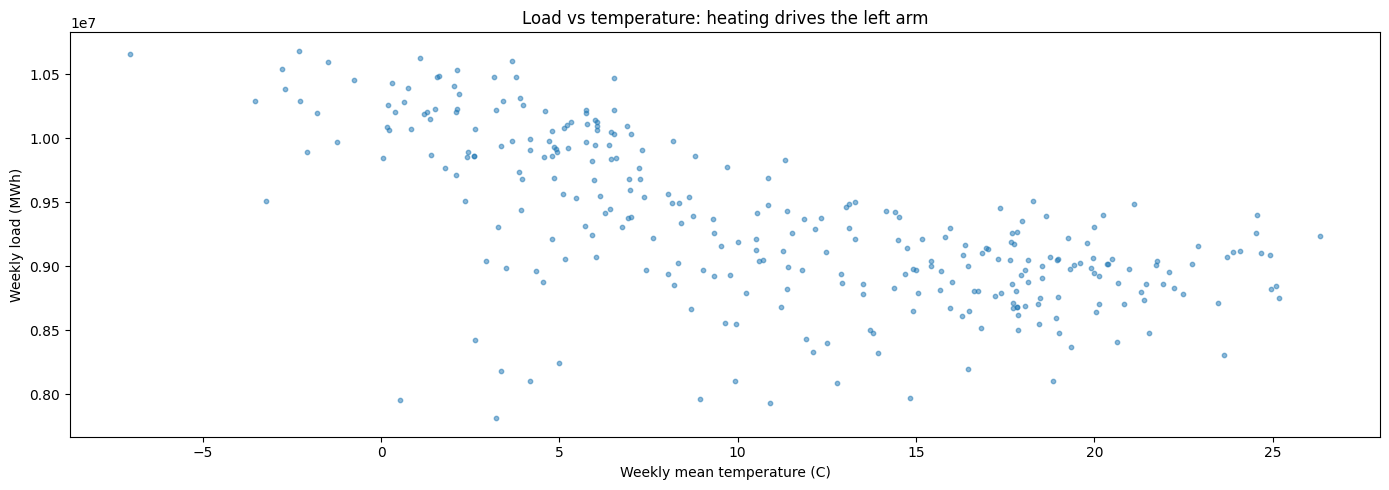

Using SARIMA order (2, 2, 6)(1, 1, 1, 52) from Part 3


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  195
Model:             SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood               -1133.654
Date:                              Fri, 17 Jul 2026   AIC                           2293.309
Time:                                      18:55:33   BIC                           2324.596
Sample:                                  01-11-2015   HQIC                          2305.870
                                       - 09-30-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hdd         1.856e+05   3.95e-06    4.7e+10      0.000    1.86e+05    1.86e+05
cdd          2.94e+

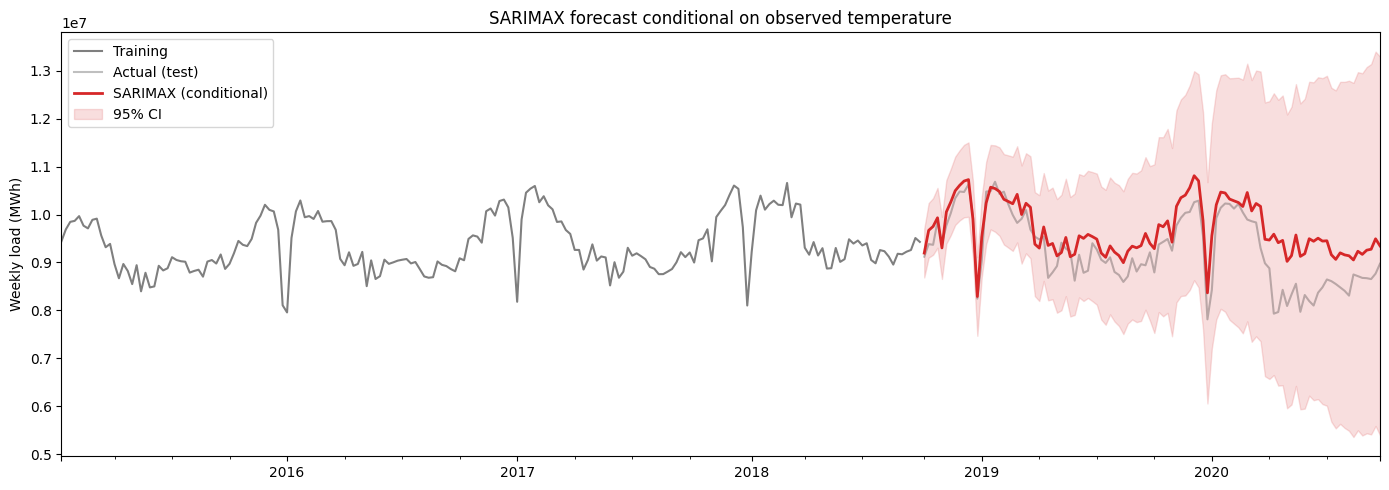


SARIMAX vs seasonal naive:
                  n       MAE      RMSE   MASE      Bias  \
model                                                      
seasonal_naive  104  384466.2  502025.7  1.694  293631.2   
sarimax         104  449604.8  563153.0  1.981  423557.5   

                RMSE_skill_vs_snaive_%  
model                                   
seasonal_naive                     0.0  
sarimax                          -12.2  
  saved forecast -> outputs/forecasts/sarimax.csv


In [5]:
# ======================================================================
# PART 4 — SARIMAX with exogenous temperature (conditional forecast)
# ======================================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------------------
# 1. Weekly load + cached weekly temperature features, aligned
# ----------------------------------------------------------------------
weekly = pd.read_csv("de_load_weekly.csv", index_col=0,
                     parse_dates=True).squeeze("columns").rename("load")
weekly_temp = get_weekly_temperature(base=18.0)          # cached; no duplicate download

df = pd.concat([weekly, weekly_temp], axis=1).dropna()
train, test = df.iloc[:-H], df.iloc[-H:]

EXOG = ["hdd", "cdd"]
y_train, X_train = train["load"], train[EXOG]
y_test,  X_test  = test["load"],  test[EXOG]

# U-shaped load-vs-temperature sanity plot
plt.scatter(df["temp_mean"], df["load"], s=10, alpha=0.5)
plt.xlabel("Weekly mean temperature (C)"); plt.ylabel("Weekly load (MWh)")
plt.title("Load vs temperature: heating drives the left arm")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig08_load_vs_temp.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 2. Standardise exog on TRAIN only (fixes the conditioning; no leakage)
# ----------------------------------------------------------------------
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=EXOG)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  index=X_test.index,  columns=EXOG)

# ----------------------------------------------------------------------
# 3. Fit SARIMAX using Part 3's best order (loaded from disk)
# ----------------------------------------------------------------------
try:
    with open("outputs/best_sarima_order.json") as f:
        b = json.load(f)
    ORDER, SEASONAL = tuple(b["order"]), tuple(b["seasonal_order"])
except FileNotFoundError:
    ORDER, SEASONAL = (1, 0, 1), (0, 1, 1, S)            # fallback if Part 3 not run
print(f"Using SARIMA order {ORDER}{SEASONAL} from Part 3")

model = SARIMAX(y_train, exog=X_train_s, order=ORDER, seasonal_order=SEASONAL,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(model.summary())

# ----------------------------------------------------------------------
# 4. Conditional forecast using OBSERVED test-period temperature
# ----------------------------------------------------------------------
fc = model.get_forecast(steps=H, exog=X_test_s)
fc_mean, fc_ci = fc.predicted_mean, fc.conf_int(alpha=0.05)

ax = y_train.plot(label="Training", color="black", alpha=0.5)
y_test.plot(ax=ax, label="Actual (test)", color="black", alpha=0.25)
fc_mean.plot(ax=ax, label="SARIMAX (conditional)", color="tab:red", linewidth=2)
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color="tab:red", alpha=0.15, label="95% CI")
ax.set_title("SARIMAX forecast conditional on observed temperature")
ax.set_ylabel("Weekly load (MWh)"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig09_sarimax_forecast.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 5. Metrics vs seasonal naive + save
# ----------------------------------------------------------------------
snaive = seasonal_naive_forecast(y_train, H, S, y_test.index)
print("\nSARIMAX vs seasonal naive:")
print(build_metric_table({"sarimax": fc_mean, "seasonal_naive": snaive}, y_test, y_train, S))
save_forecast("sarimax", fc_mean)

## Part 5 — Feature-based regression (Random Forest, Gradient Boosting)


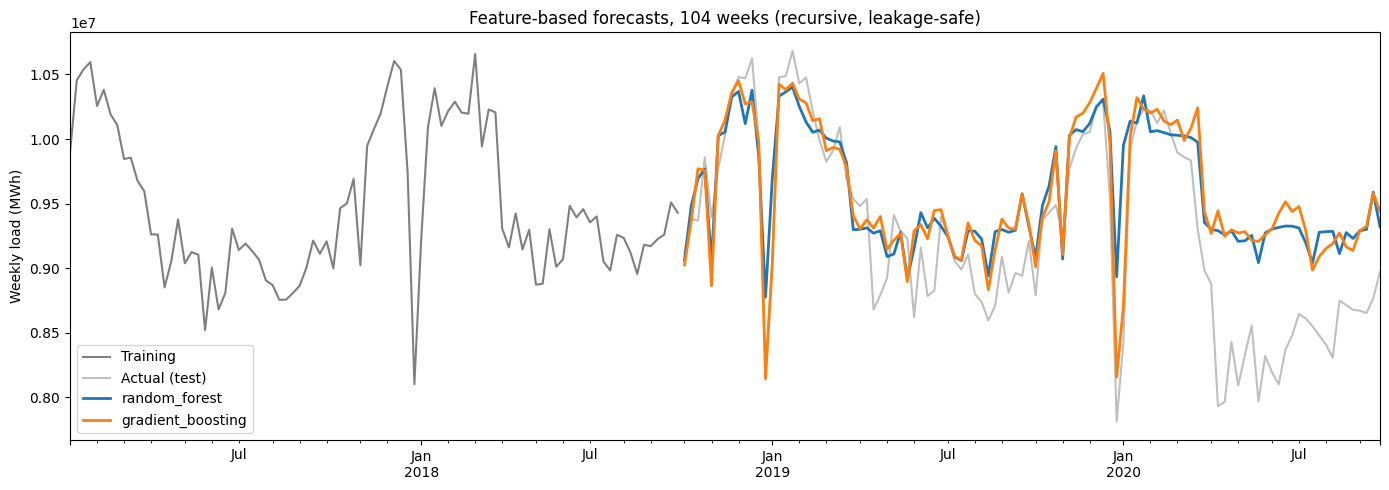

Feature models vs seasonal naive:
                     n       MAE      RMSE   MASE      Bias  \
model                                                         
gradient_boosting  104  377518.7  513196.4  1.337  306872.6   
seasonal_naive     104  384466.2  502025.7  1.362  293631.2   
random_forest      104  401288.2  531844.5  1.422  311711.5   

                   RMSE_skill_vs_snaive_%  
model                                      
gradient_boosting                    -2.2  
seasonal_naive                        0.0  
random_forest                        -5.9  


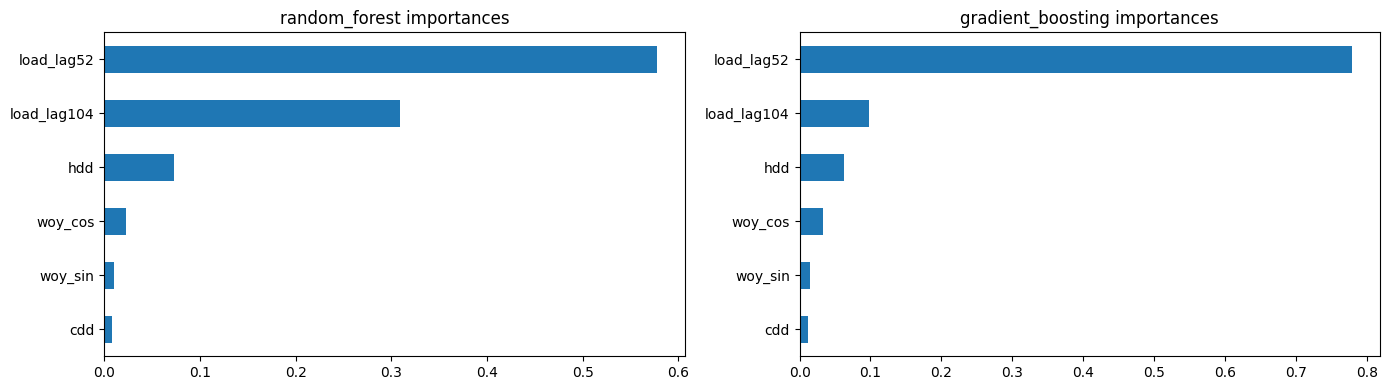

  saved forecast -> outputs/forecasts/random_forest.csv
  saved forecast -> outputs/forecasts/gradient_boosting.csv


In [6]:
# ======================================================================
# PART 5 — feature-based regression (Random Forest, Gradient Boosting)
# ======================================================================
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ----------------------------------------------------------------------
# 1. Build the feature table (cached temperature, no duplicate download)
# ----------------------------------------------------------------------
weekly = pd.read_csv("de_load_weekly.csv", index_col=0,
                     parse_dates=True).squeeze("columns").rename("load")
weekly_temp = get_weekly_temperature(base=18.0)

df = pd.concat([weekly, weekly_temp], axis=1).dropna()

# Cyclic week-of-year so week 52 sits next to week 1
woy = df.index.isocalendar().week.astype(float).values
df["woy_sin"] = np.sin(2 * np.pi * woy / S)
df["woy_cos"] = np.cos(2 * np.pi * woy / S)

# Strictly backward-looking seasonal lags
df["load_lag52"]  = df["load"].shift(52)
df["load_lag104"] = df["load"].shift(104)
df = df.dropna()

FEATURES = ["woy_sin", "woy_cos", "hdd", "cdd", "load_lag52", "load_lag104"]
TARGET   = "load"
train, test = df.iloc[:-H], df.iloc[-H:]
X_train, y_train = train[FEATURES], train[TARGET]

models = {
    "random_forest": RandomForestRegressor(n_estimators=500, min_samples_leaf=3,
                                            random_state=42),
    "gradient_boosting": GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                   max_depth=3, random_state=42),
}

# ----------------------------------------------------------------------
# 2. Leakage-safe recursive forecast of the 104-week test window
#    Year 1: 52-week lag = last training year               -> known, OK.
#    Year 2: 52-week lag = year-1 ACTUALS (unknown at origin)-> replace with
#            the model's OWN year-1 predictions (recursive multi-step).
# ----------------------------------------------------------------------
forecasts = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    X_test = test[FEATURES].copy()
    pred_y1 = model.predict(X_test.iloc[:S])                       # first test year
    X_y2 = X_test.iloc[S:].copy()
    X_y2["load_lag52"] = pred_y1[:len(X_y2)]                       # no leakage
    pred_y2 = model.predict(X_y2)
    forecasts[name] = pd.Series(np.concatenate([pred_y1, pred_y2]), index=test.index)

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
ax = train[TARGET].plot(label="Training", color="black", alpha=0.5)
test[TARGET].plot(ax=ax, label="Actual (test)", color="black", alpha=0.25)
for name, fc in forecasts.items():
    fc.plot(ax=ax, label=name, linewidth=2)
ax.set_title("Feature-based forecasts, 104 weeks (recursive, leakage-safe)")
ax.set_ylabel("Weekly load (MWh)"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig10_feature_model_forecasts.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 4. Metrics + feature importances + save
# ----------------------------------------------------------------------
snaive = seasonal_naive_forecast(y_train, H, S, test.index)
print("Feature models vs seasonal naive:")
print(build_metric_table({**forecasts, "seasonal_naive": snaive}, test[TARGET], y_train, S))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax_i, (name, model) in zip(axes, models.items()):
    pd.Series(model.feature_importances_, index=FEATURES).sort_values().plot(
        kind="barh", ax=ax_i, title=f"{name} importances")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig11_feature_importances.png", dpi=150); plt.show()

for name, fc in forecasts.items():
    save_forecast(name, fc)

## Part 6 — LSTM on hourly data (day-ahead), with a fairness caveat



{'units': 32, 'n_layers': 1, 'dropout': 0.1, 'lr': 0.001} -> val_loss=0.0897
{'units': 64, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.001} -> val_loss=0.1239
{'units': 64, 'n_layers': 2, 'dropout': 0.2, 'lr': 0.001} -> val_loss=0.1026
{'units': 128, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.0005} -> val_loss=0.1072
Best hyperparameters: {'units': 32, 'n_layers': 1, 'dropout': 0.1, 'lr': 0.001}
Epoch 1/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 0.7066 - val_loss: 0.3994
Epoch 2/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.3150 - val_loss: 0.1854
Epoch 3/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 0.2198 - val_loss: 0.1324


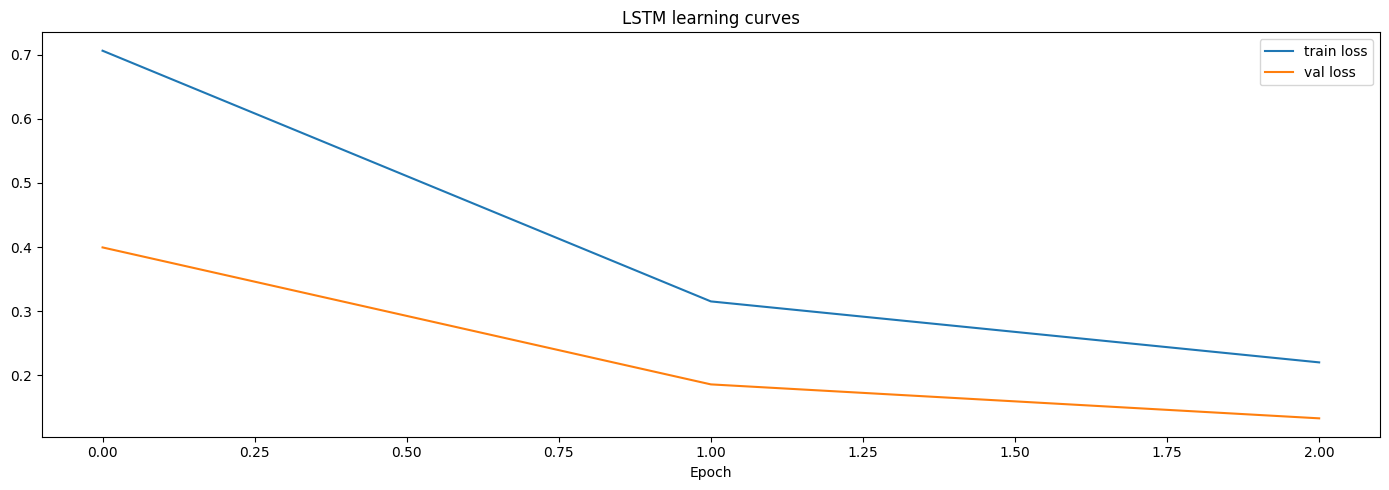

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step
LSTM day-ahead   RMSE=6,730  MAE=5,482  MAPE=10.83%
Seasonal naive   RMSE=4,290  MAE=2,489  MAPE=4.66%


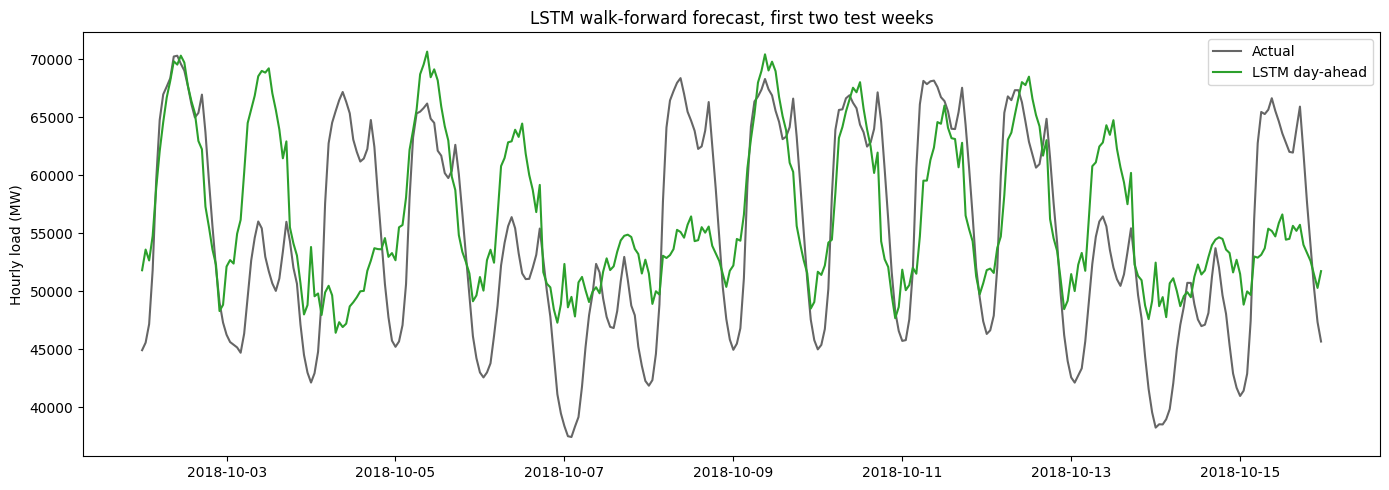

  saved forecast -> outputs/forecasts/lstm_weekly.csv

LSTM aggregated to weekly (day-ahead task; not directly comparable):
               n       MAE      RMSE   MASE      Bias
model                                                
lstm_weekly  104  389812.9  476295.0  1.717  240046.5


In [7]:
# ======================================================================
# PART 6 — LSTM day-ahead forecast on HOURLY load  (run on a GPU runtime)
# ======================================================================
import tensorflow as tf
from tensorflow.keras import layers, callbacks
tf.random.set_seed(42)

WINDOW    = 168            # input: one week of hourly history
HORIZON   = 24            # output: next 24 hours
TEST_HOURS = 2 * 8760     # final 2 years
VAL_HOURS  = 8760         # 1 year before that, for model selection

# ----------------------------------------------------------------------
# 1. Load hourly data; split train / val / test IN TIME ORDER
# ----------------------------------------------------------------------
hourly = pd.read_csv("de_load_hourly.csv", index_col=0,
                     parse_dates=True).squeeze("columns")
hourly = hourly.interpolate(limit=6).dropna()

y = hourly.values.astype("float32")
n = len(y)
train_end, val_end = n - TEST_HOURS - VAL_HOURS, n - TEST_HOURS
y_train = y[:train_end]

# ----------------------------------------------------------------------
# 2. Scale with TRAINING statistics only (leakage prevention)
# ----------------------------------------------------------------------
mu, sd = y_train.mean(), y_train.std()
scale, unscale = (lambda a: (a - mu) / sd), (lambda a: a * sd + mu)

def make_windows(series_scaled):
    X, Y = [], []
    for i in range(len(series_scaled) - WINDOW - HORIZON + 1):
        X.append(series_scaled[i:i + WINDOW])
        Y.append(series_scaled[i + WINDOW:i + WINDOW + HORIZON])
    return np.array(X)[..., None], np.array(Y)

X_tr, Y_tr = make_windows(scale(y_train))
X_va, Y_va = make_windows(scale(y[train_end - WINDOW:val_end]))   # history may reach into train

# ----------------------------------------------------------------------
# 3. Small hyperparameter search, selected on validation loss
# ----------------------------------------------------------------------
def build_model(units, n_layers, dropout, lr):
    m = tf.keras.Sequential([layers.Input(shape=(WINDOW, 1))])
    for i in range(n_layers):
        m.add(layers.LSTM(units, return_sequences=(i < n_layers - 1)))
        m.add(layers.Dropout(dropout))
    m.add(layers.Dense(HORIZON))
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return m

grid = [
    {"units": 32,  "n_layers": 1, "dropout": 0.1, "lr": 1e-3},
    {"units": 64,  "n_layers": 1, "dropout": 0.2, "lr": 1e-3},
    {"units": 64,  "n_layers": 2, "dropout": 0.2, "lr": 1e-3},
    {"units": 128, "n_layers": 2, "dropout": 0.3, "lr": 5e-4},
]
es = callbacks.EarlyStopping(patience=3, restore_best_weights=True)
log = []
for hp in grid:
    h = build_model(**hp).fit(X_tr, Y_tr, validation_data=(X_va, Y_va),
                              epochs=25, batch_size=256, callbacks=[es], verbose=0)
    log.append({**hp, "val_loss": min(h.history["val_loss"])})
    print(hp, f"-> val_loss={log[-1]['val_loss']:.4f}")

search_df = pd.DataFrame(log).sort_values("val_loss")
search_df.to_csv("lstm_hyperparameter_search.csv", index=False)
best_hp = search_df.iloc[0][["units", "n_layers", "dropout", "lr"]].to_dict()
best_hp = {k: (float(v) if k in ("dropout", "lr") else int(v)) for k, v in best_hp.items()}
print("Best hyperparameters:", best_hp)

# ----------------------------------------------------------------------
# 4. Retrain best model on train+val; learning curves
# ----------------------------------------------------------------------
X_full, Y_full = make_windows(scale(y[:val_end]))
model = build_model(**best_hp)
hist = model.fit(X_full, Y_full, validation_split=0.1, epochs=25,
                 batch_size=256, callbacks=[es], verbose=1)

plt.plot(hist.history["loss"], label="train loss")
plt.plot(hist.history["val_loss"], label="val loss")
plt.title("LSTM learning curves"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig12_lstm_learning_curves.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 5. Walk-forward day-ahead forecast over the final 2 years
#    Each day conditions on the ACTUAL previous 168 hours.
# ----------------------------------------------------------------------
context = scale(y[val_end - WINDOW:])
n_days = len(y[val_end:]) // HORIZON
X_steps = np.array([context[d*HORIZON: d*HORIZON + WINDOW] for d in range(n_days)])[..., None]
preds = unscale(model.predict(X_steps, batch_size=256).ravel())
actual = y[val_end: val_end + n_days * HORIZON]
pred_index = hourly.index[val_end: val_end + len(actual)]
pred_series = pd.Series(preds, index=pred_index)

# ----------------------------------------------------------------------
# 6. Metrics + plots
# ----------------------------------------------------------------------
snaive_h = y[val_end - 168: val_end - 168 + len(actual)]      # same hour last week
print(f"LSTM day-ahead   RMSE={rmse(actual, preds):,.0f}  "
      f"MAE={mae(actual, preds):,.0f}  MAPE={mape(actual, preds):.2f}%")
print(f"Seasonal naive   RMSE={rmse(actual, snaive_h):,.0f}  "
      f"MAE={mae(actual, snaive_h):,.0f}  MAPE={mape(actual, snaive_h):.2f}%")

zoom = slice(0, 24 * 14)
plt.plot(pred_index[zoom], actual[zoom], label="Actual", color="black", alpha=0.6)
plt.plot(pred_index[zoom], preds[zoom],  label="LSTM day-ahead", color="tab:green")
plt.title("LSTM walk-forward forecast, first two test weeks")
plt.ylabel("Hourly load (MW)"); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig13_lstm_forecast_zoom.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 7. Aggregate to weekly and align to the SAME weekly test window as the
#    other models (calendar-consistent), then save for Part 7.
#    NOTE: still a DAY-AHEAD task -> flagged in the Part 7 table.
# ----------------------------------------------------------------------
weekly_ref  = pd.read_csv("de_load_weekly.csv", index_col=0,
                          parse_dates=True).squeeze("columns")
weekly_test_index = weekly_ref.iloc[-H:].index
weekly_train      = weekly_ref.iloc[:-H]

lstm_weekly = pred_series.resample("W").sum().reindex(weekly_test_index)
save_forecast("lstm_weekly", lstm_weekly)

print("\nLSTM aggregated to weekly (day-ahead task; not directly comparable):")
print(build_metric_table({"lstm_weekly": lstm_weekly}, weekly_ref.iloc[-H:], weekly_train, S))

## Part 7 — Cross-model comparison and error analysis



Forecasts found: drift, gradient_boosting, lstm_weekly, mean, naive, random_forest, sarima, sarimax, seasonal_naive

Saved -> outputs/metrics/model_comparison.csv

                     n        MAE       RMSE   MASE       Bias  \
model                                                            
gradient_boosting  104   377518.7   513196.4  1.663   306872.6   
seasonal_naive     104   384466.2   502025.7  1.694   293631.2   
lstm_weekly        104   389812.9   476295.0  1.717   240046.5   
random_forest      104   401288.2   531844.5  1.768   311711.5   
sarimax            104   449604.8   563153.0  1.981   423557.5   
mean               104   636694.0   739545.9  2.805    94280.3   
drift              104   646930.3   750371.1  2.850   162352.8   
naive              104   648168.8   751928.9  2.856   165401.6   
sarima             104  1187632.6  1388509.7  5.232  1187632.6   

                   RMSE_skill_vs_snaive_%  
model                                      
gradient_boosting    

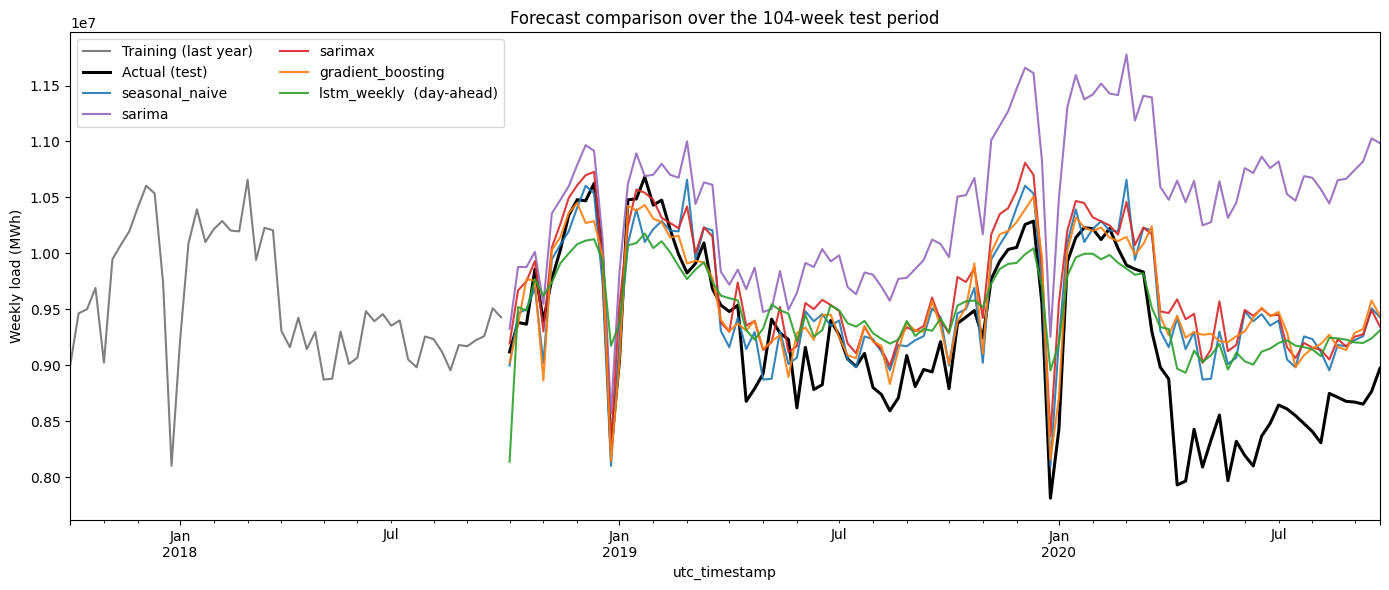

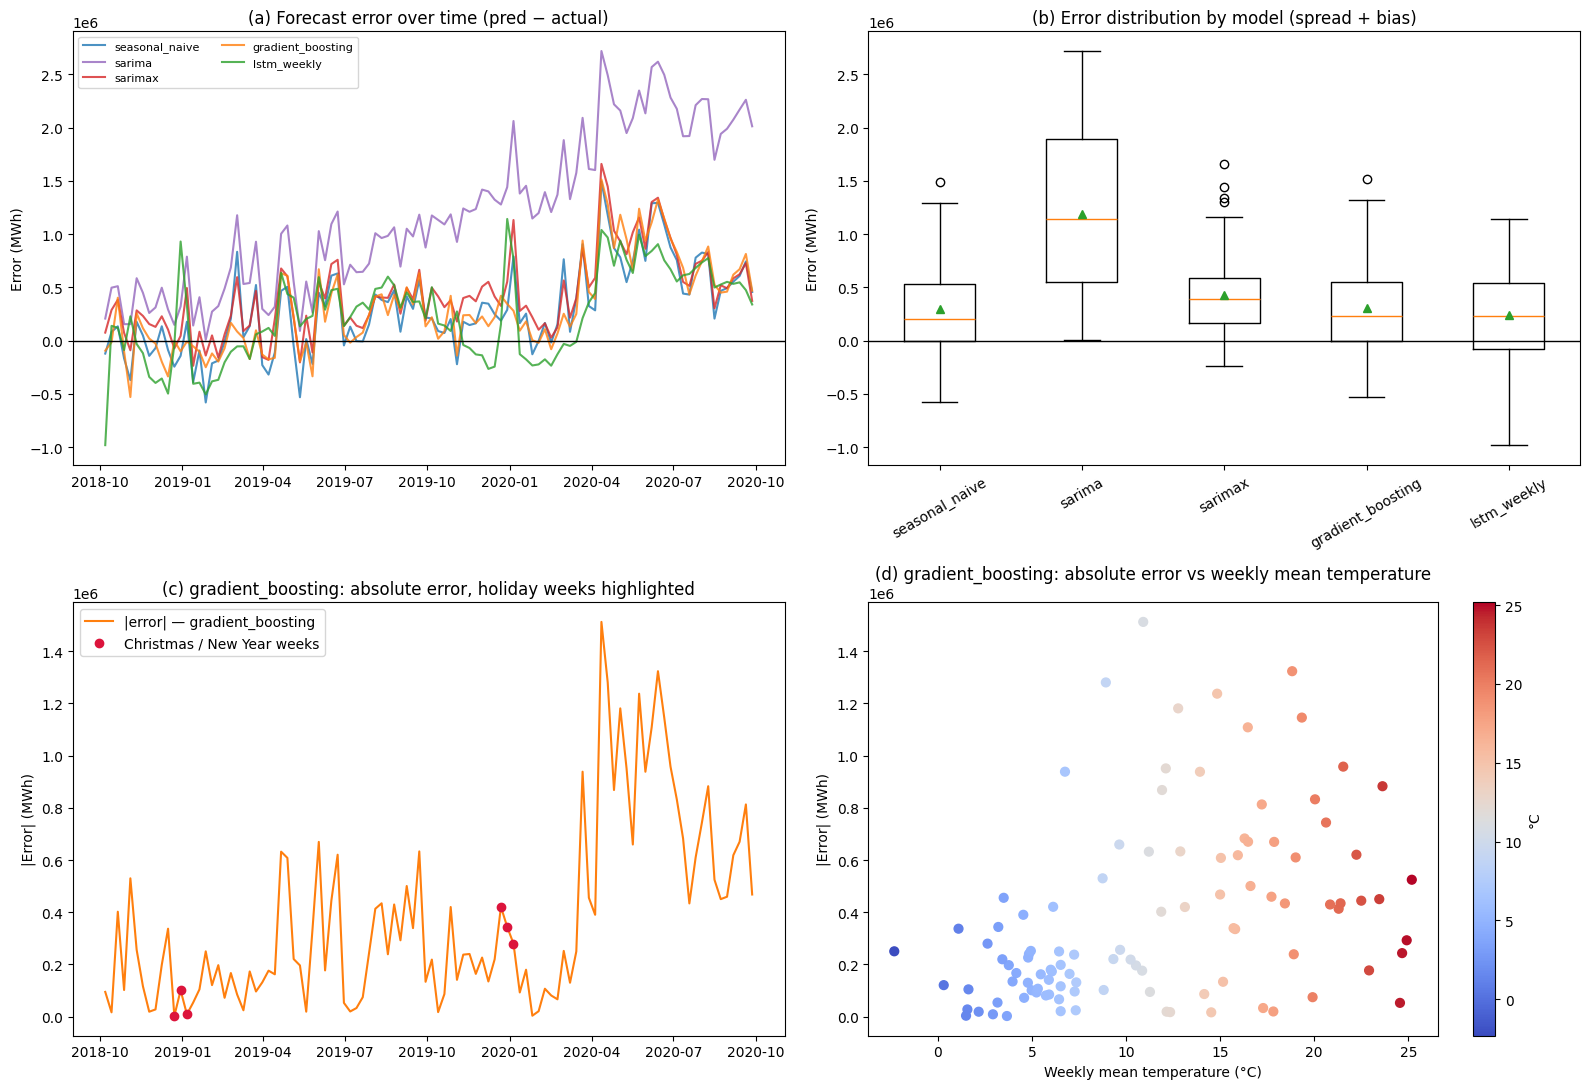


EVIDENCE FOR THE PART-7 REPORT QUESTIONS

Q1  Improvement vs seasonal-naive benchmark (104-week horizon):
   gradient_boosting  RMSE      513,196  ( -2.2% vs snaive -> worse than benchmark)
   random_forest      RMSE      531,844  ( -5.9% vs snaive -> worse than benchmark)
   sarimax            RMSE      563,153  (-12.2% vs snaive -> worse than benchmark)
   mean               RMSE      739,546  (-47.3% vs snaive -> worse than benchmark)
   drift              RMSE      750,371  (-49.5% vs snaive -> worse than benchmark)
   naive              RMSE      751,929  (-49.8% vs snaive -> worse than benchmark)
   sarima             RMSE    1,388,510  (-176.6% vs snaive -> worse than benchmark)
   -> Best genuine 2-year-ahead model: 'seasonal_naive'.
   -> Advanced models beating snaive by >5% RMSE: NONE (seasonal naive is hard to beat here)

Q3/Q4  Do temperature covariates help? SARIMA vs SARIMAX:
   SARIMA  RMSE    1,388,510
   SARIMAX RMSE      563,153  (exog temperature changes RMSE by +8

In [8]:
# ======================================================================
# PART 7 — cross-model comparison and error analysis
#   Loads every saved test-period forecast, scores them all on ONE
#   104-week window with the SAME metrics, and produces the two summary
#   figures the brief/README asks for.  Nothing is hard-coded: the table
#   and the printed conclusions are derived from whatever Parts 2-6 saved.
# ======================================================================

# ----------------------------------------------------------------------
# 1. Canonical target and the same train/test split used in Parts 2-3
# ----------------------------------------------------------------------
weekly = pd.read_csv("de_load_weekly.csv", index_col=0,
                     parse_dates=True).squeeze("columns").rename("load")
train, test = weekly.iloc[:-H], weekly.iloc[-H:]

# Collect every forecast Parts 2-6 wrote to outputs/forecasts/*.csv
all_fc = load_all_forecasts()
print("Forecasts found:", ", ".join(sorted(all_fc)))

# ----------------------------------------------------------------------
# 2. One unified metric table (MAE, RMSE, MASE, Bias, RMSE skill vs snaive)
# ----------------------------------------------------------------------
table = build_metric_table(all_fc, test, train, S)
table.to_csv(MET_DIR / "model_comparison.csv")
print(f"\nSaved -> {MET_DIR / 'model_comparison.csv'}\n")
print(table)

# lstm_weekly is a DAY-AHEAD task aggregated to weekly, so it is NOT a
# like-for-like 104-week-ahead forecast.  Keep it out of the "which model
# wins the 2-year horizon" decision but still show it in the table/plots.
DAY_AHEAD = {"lstm_weekly"}
BENCHMARKS = {"mean", "naive", "seasonal_naive", "drift"}

multistep = [m for m in table.index if m not in DAY_AHEAD]
advanced  = [m for m in multistep if m not in BENCHMARKS]        # sarima(x), RF, GB
snaive_rmse = table.loc["seasonal_naive", "RMSE"] if "seasonal_naive" in table.index else np.nan

# Best genuine 104-week-ahead model, and best *advanced* model, by RMSE
best_overall  = table.loc[multistep, "RMSE"].idxmin()
best_advanced = table.loc[advanced,  "RMSE"].idxmin() if advanced else None

# ----------------------------------------------------------------------
# 3. Figure 1 — forecast_comparison.png  (actual + a readable subset)
# ----------------------------------------------------------------------
CURATED = ["seasonal_naive", "sarima", "sarimax", "gradient_boosting", "lstm_weekly"]
COLORS  = {"seasonal_naive": "tab:blue", "sarima": "tab:purple",
           "sarimax": "tab:red", "gradient_boosting": "tab:orange",
           "random_forest": "tab:brown", "lstm_weekly": "tab:green"}

fig, ax = plt.subplots(figsize=(14, 6))
train.iloc[-S:].plot(ax=ax, color="black", alpha=0.5, label="Training (last year)")
test.plot(ax=ax, color="black", linewidth=2.2, label="Actual (test)")
for m in CURATED:
    if m in all_fc:
        label = m + "  (day-ahead)" if m in DAY_AHEAD else m
        all_fc[m].reindex(test.index).plot(ax=ax, color=COLORS.get(m), alpha=0.9, label=label)
ax.set_title("Forecast comparison over the 104-week test period")
ax.set_ylabel("Weekly load (MWh)"); ax.legend(ncol=2)
plt.tight_layout(); plt.savefig(FIG_DIR / "forecast_comparison.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 4. Figure 2 — error_diagnostics.png  (2x2)
#    (a) errors over time   (b) error distribution by model
#    (c) |error| around Christmas / New Year   (d) |error| vs temperature
# ----------------------------------------------------------------------
# Signed error frames for a readable subset (skip weeks a model didn't cover)
err = {m: (all_fc[m].reindex(test.index) - test)
       for m in CURATED if m in all_fc}

# Weekly mean temperature aligned to the test window (cached from Parts 4/5)
wtemp = get_weekly_temperature(base=18.0).reindex(test.index)
iso_week = test.index.isocalendar().week.to_numpy()
xmas_mask = (iso_week >= 51) | (iso_week <= 1)          # holiday weeks

# Absolute error of the best advanced model (fall back to best_overall)
focus = best_advanced or best_overall
abs_err_focus = (all_fc[focus].reindex(test.index) - test).abs()

fig, ax = plt.subplots(2, 2, figsize=(16, 11))

# (a) signed error over the test period
for m, e in err.items():
    ax[0, 0].plot(e.index, e.values, color=COLORS.get(m), alpha=0.8, label=m)
ax[0, 0].axhline(0, color="black", lw=1)
ax[0, 0].set_title("(a) Forecast error over time (pred − actual)")
ax[0, 0].set_ylabel("Error (MWh)"); ax[0, 0].legend(ncol=2, fontsize=8)

# (b) error distribution by model
names = list(err.keys())
ax[0, 1].boxplot([err[m].dropna().values for m in names], labels=names, showmeans=True)
ax[0, 1].axhline(0, color="black", lw=1)
ax[0, 1].set_title("(b) Error distribution by model (spread + bias)")
ax[0, 1].set_ylabel("Error (MWh)")
ax[0, 1].tick_params(axis="x", rotation=30)

# (c) absolute error of the focus model, holiday weeks highlighted
ax[1, 0].plot(abs_err_focus.index, abs_err_focus.values,
              color=COLORS.get(focus, "tab:red"), label=f"|error| — {focus}")
ax[1, 0].scatter(abs_err_focus.index[xmas_mask], abs_err_focus.values[xmas_mask],
                 color="crimson", zorder=5, label="Christmas / New Year weeks")
ax[1, 0].set_title(f"(c) {focus}: absolute error, holiday weeks highlighted")
ax[1, 0].set_ylabel("|Error| (MWh)"); ax[1, 0].legend()

# (d) absolute error vs weekly mean temperature (extreme-weather check)
sc = ax[1, 1].scatter(wtemp["temp_mean"].to_numpy(), abs_err_focus.to_numpy(),
                      c=wtemp["temp_mean"].to_numpy(), cmap="coolwarm", s=40)
ax[1, 1].set_title(f"(d) {focus}: absolute error vs weekly mean temperature")
ax[1, 1].set_xlabel("Weekly mean temperature (°C)"); ax[1, 1].set_ylabel("|Error| (MWh)")
plt.colorbar(sc, ax=ax[1, 1], label="°C")

plt.tight_layout(); plt.savefig(FIG_DIR / "error_diagnostics.png", dpi=150); plt.show()

# ----------------------------------------------------------------------
# 5. Numerical evidence for the six Part-7 report questions
# ----------------------------------------------------------------------
def beats(m):                       # % RMSE improvement over seasonal naive
    return (snaive_rmse - table.loc[m, "RMSE"]) / snaive_rmse * 100

print("\n" + "=" * 70)
print("EVIDENCE FOR THE PART-7 REPORT QUESTIONS")
print("=" * 70)

print("\nQ1  Improvement vs seasonal-naive benchmark (104-week horizon):")
for m in multistep:
    if m == "seasonal_naive":
        continue
    d = beats(m)
    verdict = "beats" if d > 0 else "worse than"
    print(f"   {m:<18} RMSE {table.loc[m,'RMSE']:>12,.0f}  "
          f"({d:+5.1f}% vs snaive -> {verdict} benchmark)")
print(f"   -> Best genuine 2-year-ahead model: '{best_overall}'.")
meaningful = [m for m in advanced if beats(m) > 5]
print(f"   -> Advanced models beating snaive by >5% RMSE: "
      f"{meaningful if meaningful else 'NONE (seasonal naive is hard to beat here)'}")

print("\nQ3/Q4  Do temperature covariates help? SARIMA vs SARIMAX:")
if {"sarima", "sarimax"} <= set(table.index):
    delta = table.loc["sarima", "RMSE"] - table.loc["sarimax", "RMSE"]
    print(f"   SARIMA  RMSE {table.loc['sarima','RMSE']:>12,.0f}")
    print(f"   SARIMAX RMSE {table.loc['sarimax','RMSE']:>12,.0f}  "
          f"(exog temperature changes RMSE by {delta:+,.0f})")
    print("   Note: SARIMAX here is a CONDITIONAL forecast (uses observed test-period")
    print("   temperature); temperature is NOT known at a true forecast origin.")

print("\nError analysis (from figure 2):")
print(f"   Holiday weeks (Christmas/New Year), mean |error| for '{focus}': "
      f"{abs_err_focus[xmas_mask].mean():,.0f} MWh  vs "
      f"{abs_err_focus[~xmas_mask].mean():,.0f} MWh on normal weeks.")
corr = np.corrcoef(wtemp['temp_mean'].values, abs_err_focus.values)[0, 1]
print(f"   Corr(|error|, weekly mean temp) for '{focus}': {corr:+.2f} "
      f"(sign shows whether extreme temperatures inflate errors).")

print("\nBias direction (mean pred − actual; >0 = over-forecast):")
for m in multistep:
    print(f"   {m:<18} Bias {table.loc[m,'Bias']:>+12,.0f}")
print("\n(See the answers cell below for the written Q2/Q5/Q6 responses.)")